In [75]:
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F

# Data Import, Visualize, Normalize

In [11]:
train = h5py.File(name="../../Datasets/CNN/train_signs.h5", mode='r')
test = h5py.File(name="../../Datasets/CNN/test_signs.h5", mode='r')

In [12]:
train.keys(), test.keys()

(<KeysViewHDF5 ['list_classes', 'train_set_x', 'train_set_y']>,
 <KeysViewHDF5 ['list_classes', 'test_set_x', 'test_set_y']>)

In [20]:
classes = torch.tensor(np.array(train.get('list_classes')))
x_train = torch.tensor(np.array(train.get('train_set_x')))
x_test = torch.tensor(np.array(test.get('test_set_x')))
y_train = torch.tensor(np.array(train.get('train_set_y')))
y_test = torch.tensor(np.array(test.get('test_set_y')))

In [121]:
num_classes = len(classes)

In [21]:
classes

tensor([0, 1, 2, 3, 4, 5])

In [24]:
((x_train.shape, y_train.shape), (x_test.shape, y_test.shape))

((torch.Size([1080, 64, 64, 3]), torch.Size([1080])),
 (torch.Size([120, 64, 64, 3]), torch.Size([120])))

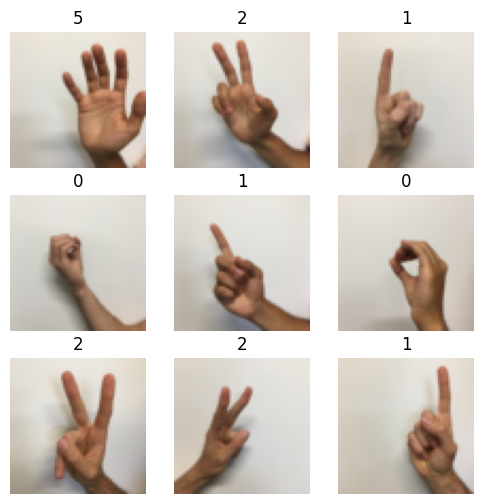

In [68]:
fig, axes = plt.subplots(3,3, figsize=(6,6))
idx = torch.randint(0, x_train.shape[0], size=(9,))
#print(idx)
for i in range(9):
    index = idx[i]
    subplt = axes[i//3, i%3]
    subplt.imshow(x_train[index])
    subplt.axis("off")
    subplt.set_title(y_train[index].item())
    
plt.show()

In [77]:
print(f"{x_train[0].shape=},\n{x_train.min().item()=},\n{x_train.max().item()=}")

x_train[0].shape=torch.Size([64, 64, 3]),
x_train.min().item()=4,
x_train.max().item()=244


In [147]:
x_train_norm = x_train/255.0
x_test_norm = x_test/255.0

print(f"{x_train[0].shape=},\n{x_train_norm.min().item()=},\n{x_train_norm.max().item()=}\n\n")
print(f"Before normalization: \n{x_train_norm.mean(dim=[0,1,2])=},\n{x_train_norm.std(dim=[0,1,2])=}\n\n")

x_train_norm_mean = x_train_norm.mean(dim=[0,1,2], keepdim=True) #across all the data in a channel
x_train_norm_std = x_train_norm.std(dim=[0,1,2], keepdim=True) + 1e-9
print(f"Mean and std shape: {x_train_norm_mean.shape}")
x_train_norm = (x_train_norm - x_train_norm_mean)/x_train_norm_std
print(f"After normalization: \n{x_train_norm.mean(dim=[0,1,2])=},\n{x_train_norm.std(dim=[0,1,2])=}\n\n")


x_test_norm = (x_test_norm - x_train_norm_mean)/x_train_norm_std
print(f"Test data after normalization with mean & std of training data: ")
print(f"{x_test_norm.mean(dim=[0,1,2])=},\n{x_test_norm.std(dim=[0,1,2])=}")

x_train_norm = x_train_norm.permute(0,3,1,2) #to match the input accepted by the pytorch convolution
x_test_norm = x_test_norm.permute(0,3,1,2)

print(f"{x_train_norm.shape=}")

x_train[0].shape=torch.Size([64, 64, 3]),
x_train_norm.min().item()=0.01568627543747425,
x_train_norm.max().item()=0.95686274766922


Before normalization: 
x_train_norm.mean(dim=[0,1,2])=tensor([0.7630, 0.7105, 0.6634]),
x_train_norm.std(dim=[0,1,2])=tensor([0.1538, 0.1998, 0.2221])


Mean and std shape: torch.Size([1, 1, 1, 3])
After normalization: 
x_train_norm.mean(dim=[0,1,2])=tensor([ 2.2869e-07, -1.3669e-07, -7.7403e-08]),
x_train_norm.std(dim=[0,1,2])=tensor([1., 1., 1.])


Test data after normalization with mean & std of training data: 
x_test_norm.mean(dim=[0,1,2])=tensor([0.0097, 0.0055, 0.0049]),
x_test_norm.std(dim=[0,1,2])=tensor([0.9866, 0.9910, 0.9903])
x_train_norm.shape=torch.Size([1080, 3, 64, 64])


In [153]:
y_train_oh = F.one_hot(y_train, num_classes=num_classes) * 1.0
y_test_oh = F.one_hot(y_test, num_classes=num_classes) * 1.0

# Build a CNN

In [509]:
# image size (n, 3, 64, 64)
conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size=3, stride=1, padding=0)
nn.init.kaiming_normal_(conv1.weight) #don't use xavier init as xavier is for sigmoid/tanh kind of activations

conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1, padding="valid")
nn.init.kaiming_normal_(conv2.weight)

linear1 = nn.Linear(in_features=16*14*14, out_features=1024)
nn.init.kaiming_normal_(linear1.weight, nonlinearity='relu')

linear2 = nn.Linear(in_features=1024, out_features=128)
nn.init.kaiming_normal_(linear2.weight, nonlinearity='relu')

linear3 = nn.Linear(in_features=128, out_features=num_classes)
with torch.no_grad():
    linear3.weight.mul_(0.1) # to have low confidence

layers = [
    conv1,                                  # (n, 6, 62, 62)
    nn.BatchNorm2d(num_features=6),
    nn.ReLU(),                              # (n, 6, 62, 62)
    nn.MaxPool2d(kernel_size=2, stride=2),  # (n, 6, 31, 31)
    conv2,                                  # (n, 16, 29, 29)
    nn.BatchNorm2d(num_features=16),
    nn.ReLU(),                              # (n, 16, 29, 29)
    nn.MaxPool2d(kernel_size=2, stride=2),  # (n, 16, 14, 14)
    nn.Flatten(),                           # (n, 3136)
    linear1,                                # (n, 1024)
    nn.BatchNorm1d(num_features=1024),
    nn.ReLU(),                              # (n, 1024)
    linear2,                                # (n, 128)
    nn.BatchNorm1d(num_features=128),
    nn.ReLU(),                              # (n, 128)
    linear3                                 # (n, 6)
]

model = nn.Sequential(*layers)

In [510]:
epochs = 10
losses = []
optimizer = torch.optim.SGD(model.parameters(), lr = 0.02) #works badly, with all other variables of the NN kept the same.
optimizer = torch.optim.Adam(model.parameters(), lr = 0.005) #higher value of lr, explodes the losses
own_optim = False

for epoch in range(epochs):
    
    logits = model(x_train_norm)
    loss = F.cross_entropy(logits, y_train_oh)
    losses.append(loss.item())

    print(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

1.7920640707015991
1.6312570571899414
1.4102510213851929
1.206636667251587
1.0145909786224365
0.8335028886795044
0.6665422916412354
0.5177491307258606
0.389842689037323
0.284638375043869


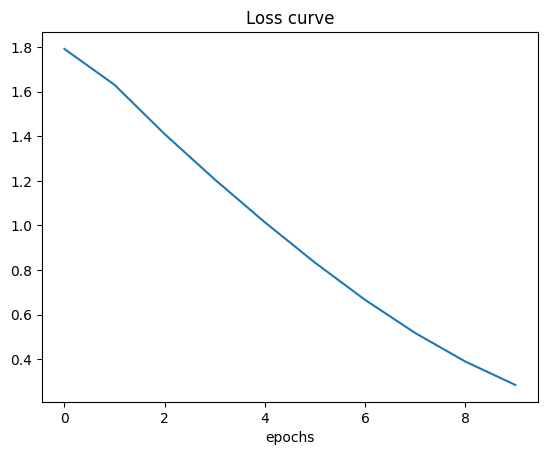

In [511]:
plt.plot(losses)
plt.title("Loss curve")
plt.xlabel("epochs")
plt.show()

In [512]:
with torch.no_grad():
    n_train = x_train.shape[0]
    logits = model(x_train_norm)
    y_train_pred = F.softmax(logits, dim=1).argmax(dim=1)
    print(y_train_pred)
    misses = (y_train_pred != y_train).sum().item()
    print(f"Train Accuracy: {(n_train-misses)/n_train*100:.2f}%")
    
    n_test = x_train.shape[0]
    logits = model(x_test_norm)
    y_test_pred = F.softmax(logits, dim=1).argmax(dim=1)
    misses = (y_test_pred != y_test).sum().item()
    print(f"Test Accuracy: {(n_test-misses)/n_test*100:.2f}%")
    

tensor([5, 0, 2,  ..., 2, 4, 5])
Train Accuracy: 99.17%
Test Accuracy: 99.35%


tensor([0])


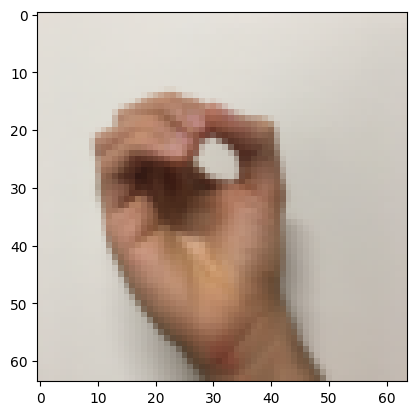

In [513]:
# Predict
idx = torch.randint(0, n_train, size=(1,))
x = x_train_norm[idx]
with torch.no_grad():
    model.eval()
    logits = model(x)
    y_train_pred = F.softmax(logits, dim=1).argmax(dim=1)
    print(y_train_pred)
    
plt.imshow(x_train[idx].squeeze(dim=0))
plt.show()

tensor([4])


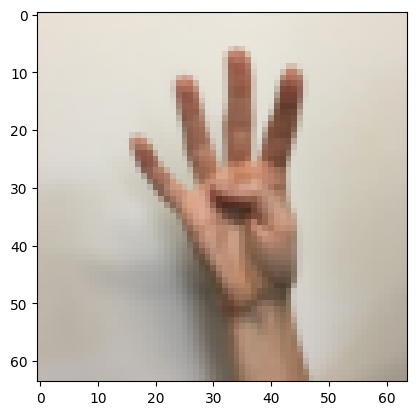

In [514]:
# Predict
idx = torch.randint(0, n_train, size=(1,))
x = x_train_norm[idx]
with torch.no_grad():
    model.eval()
    logits = model(x)
    y_train_pred = F.softmax(logits, dim=1).argmax(dim=1)
    print(y_train_pred)
    
plt.imshow(x_train[idx].squeeze(dim=0))
plt.show()

for the hand symbol: 2


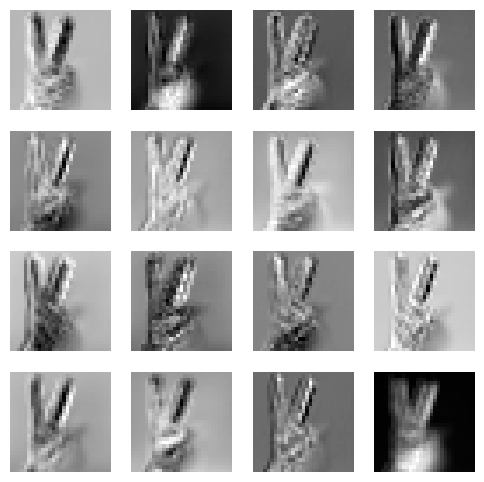

In [525]:
# Predict
idx = torch.randint(0, n_train, size=(1,))
print(f"for the hand symbol: {y_train[idx].item()}")
x = x_train_norm[idx]
with torch.no_grad():
    for i in range(6):
        x = layers[i](x)
    #print(x.squeeze(0).shape)
    x = x.squeeze(0)

_, axes = plt.subplots(nrows=4, ncols=4, figsize=(6,6))
for i in range(16):
    subplt = axes[i//4, i%4]
    subplt.axis("off")
    subplt.imshow(x[i], cmap='grey')
plt.show()